# Experiment: Balanced ARCADE EDA (Syntax + Stenosis)

**Objective**
- Build an EDA-first understanding of ARCADE (`syntax` + `stenosis`) across `train`, `val`, and `test`.
- Assess structure, label distributions, annotation geometry, image statistics, and split drift.
- Run a focused cross-split leakage audit (exact + near duplicates) as a secondary section.

**Success Criteria**
- All charts use seaborn.
- Notebook is self-contained and runnable top-to-bottom.
- Final conclusions provide per-task EDA health and leakage-risk verdicts with actionable recommendations.


In [3]:
%pip install -q --upgrade numpy pandas seaborn matplotlib pillow scipy scikit-image scikit-learn


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [4]:
from __future__ import annotations

import hashlib
import json
import warnings
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from scipy.fft import dct
from skimage.metrics import structural_similarity as ssim
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

sns.set_theme(style="whitegrid", context="notebook", palette="Set2")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## Configuration And Core Helpers

This section defines the required local helper interfaces:
- `load_task_split(task, split)`
- `build_image_stats(task, split)`
- `summarize_eda(images_df, annotations_df)`
- `find_cross_split_leakage(task, split_a, split_b)` (defined later in leakage section)


In [5]:
DATASET_ROOT = Path("datasets/arcade/data")
TASKS = ["syntax", "stenosis"]
SPLITS = ["train", "val", "test"]
PRIMARY_SPLIT_PAIR = ("train", "test")

LEAKAGE_THRESHOLDS = {
    "high": {"phash": 2, "ssim": 0.96, "corr": 0.98},
    "medium": {"phash": 4, "ssim": 0.92, "corr": 0.94},
    "low": {"phash": 6, "ssim": 0.88, "corr": 0.90},
}

if not DATASET_ROOT.exists():
    raise FileNotFoundError(f"Dataset root not found: {DATASET_ROOT}")


def compute_md5(path: Path, chunk_size: int = 1 << 20) -> str:
    hasher = hashlib.md5()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            hasher.update(chunk)
    return hasher.hexdigest()


def phash64(image: Image.Image, hash_size: int = 8, highfreq_factor: int = 4) -> int:
    resized = image.convert("L").resize(
        (hash_size * highfreq_factor, hash_size * highfreq_factor),
        Image.Resampling.LANCZOS,
    )
    arr = np.asarray(resized, dtype=np.float32)
    dct_low = dct(dct(arr, axis=0, norm="ortho"), axis=1, norm="ortho")[:hash_size, :hash_size]
    median = np.median(dct_low[1:, 1:])
    bits = dct_low > median

    hash_value = 0
    for bit in bits.flatten():
        hash_value = (hash_value << 1) | int(bool(bit))
    return int(hash_value)


def load_task_split(task: str, split: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    ann_path = DATASET_ROOT / task / split / "annotations" / f"{split}.json"
    if not ann_path.exists():
        raise FileNotFoundError(f"Missing annotation file: {ann_path}")

    data = json.loads(ann_path.read_text())
    images_df = pd.DataFrame(data.get("images", [])).copy()
    annotations_df = pd.DataFrame(data.get("annotations", [])).copy()
    categories_df = pd.DataFrame(data.get("categories", [])).copy()

    if "id" in images_df.columns:
        images_df["id"] = images_df["id"].astype(int)
    if "image_id" in annotations_df.columns:
        annotations_df["image_id"] = annotations_df["image_id"].astype(int)
    if "category_id" in annotations_df.columns:
        annotations_df["category_id"] = annotations_df["category_id"].astype(int)
    if "id" in categories_df.columns:
        categories_df["id"] = categories_df["id"].astype(int)

    return images_df, annotations_df, categories_df


def build_image_stats(task: str, split: str) -> pd.DataFrame:
    image_dir = DATASET_ROOT / task / split / "images"
    if not image_dir.exists():
        raise FileNotFoundError(f"Missing image dir: {image_dir}")

    rows: list[dict] = []
    for image_path in sorted(image_dir.glob("*.png")):
        with Image.open(image_path) as img:
            gray_arr = np.asarray(img.convert("L"), dtype=np.float32)
            rows.append(
                {
                    "task": task,
                    "split": split,
                    "file_name": image_path.name,
                    "path": str(image_path),
                    "width": int(img.width),
                    "height": int(img.height),
                    "mode": img.mode,
                    "mean_intensity": float(gray_arr.mean()),
                    "std_intensity": float(gray_arr.std()),
                    "md5": compute_md5(image_path),
                    "phash": phash64(img),
                }
            )

    return pd.DataFrame(rows)


def summarize_eda(images_df: pd.DataFrame, annotations_df: pd.DataFrame) -> dict:
    summary = {
        "n_images": int(len(images_df)),
        "n_annotations": int(len(annotations_df)),
        "mode_distribution": {},
        "mean_intensity_mean": np.nan,
        "mean_intensity_std": np.nan,
        "std_intensity_mean": np.nan,
        "annotations_per_image_mean": np.nan,
        "annotations_per_image_median": np.nan,
    }

    if not images_df.empty:
        if "mode" in images_df.columns:
            summary["mode_distribution"] = images_df["mode"].value_counts().to_dict()
        if "mean_intensity" in images_df.columns:
            summary["mean_intensity_mean"] = float(images_df["mean_intensity"].mean())
            summary["mean_intensity_std"] = float(images_df["mean_intensity"].std(ddof=0))
        if "std_intensity" in images_df.columns:
            summary["std_intensity_mean"] = float(images_df["std_intensity"].mean())

    if not annotations_df.empty and "image_id" in annotations_df.columns:
        ann_per_img = annotations_df.groupby("image_id").size()
        summary["annotations_per_image_mean"] = float(ann_per_img.mean())
        summary["annotations_per_image_median"] = float(ann_per_img.median())

    return summary


def _bbox_component(bbox: object, index: int) -> float:
    if isinstance(bbox, (list, tuple)) and len(bbox) > index:
        try:
            return float(bbox[index])
        except (TypeError, ValueError):
            return np.nan
    return np.nan


## Load Data, Build Unified Tables, And Run Inventory Checks


In [6]:
TASK_SPLIT_DATA: dict[tuple[str, str], dict[str, pd.DataFrame]] = {}
IMAGE_STATS_BY_KEY: dict[tuple[str, str], pd.DataFrame] = {}

images_meta_frames: list[pd.DataFrame] = []
annotation_frames: list[pd.DataFrame] = []
category_frames: list[pd.DataFrame] = []
image_stats_frames: list[pd.DataFrame] = []
inventory_rows: list[dict] = []

for task in TASKS:
    for split in SPLITS:
        images_df, annotations_df, categories_df = load_task_split(task, split)
        image_stats_df = build_image_stats(task, split)

        images_df = images_df.copy()
        annotations_df = annotations_df.copy()
        categories_df = categories_df.copy()

        images_df["task"] = task
        images_df["split"] = split

        if not annotations_df.empty:
            annotations_df["task"] = task
            annotations_df["split"] = split

        categories_df["task"] = task
        categories_df["split"] = split

        images_meta_frames.append(images_df)
        if not annotations_df.empty:
            annotation_frames.append(annotations_df)
        category_frames.append(categories_df)
        image_stats_frames.append(image_stats_df)

        TASK_SPLIT_DATA[(task, split)] = {
            "images": images_df,
            "annotations": annotations_df,
            "categories": categories_df,
            "image_stats": image_stats_df,
        }
        IMAGE_STATS_BY_KEY[(task, split)] = image_stats_df

        image_dir = DATASET_ROOT / task / split / "images"
        actual_files = sorted(p.name for p in image_dir.glob("*.png"))
        json_files = sorted(images_df["file_name"].tolist()) if "file_name" in images_df.columns else []

        image_ids = set(images_df["id"].tolist()) if "id" in images_df.columns else set()
        annotation_image_ids = set(annotations_df["image_id"].tolist()) if "image_id" in annotations_df.columns else set()

        inventory_rows.append(
            {
                "task": task,
                "split": split,
                "dir_images": len(actual_files),
                "json_images": int(len(images_df)),
                "json_annotations": int(len(annotations_df)),
                "json_categories": int(len(categories_df)),
                "missing_image_files": len(set(json_files) - set(actual_files)),
                "extra_image_files": len(set(actual_files) - set(json_files)),
                "orphan_annotation_image_ids": len(annotation_image_ids - image_ids),
                "images_without_annotations": len(image_ids - annotation_image_ids),
            }
        )

all_images_meta = pd.concat(images_meta_frames, ignore_index=True)
all_categories = pd.concat(category_frames, ignore_index=True)
all_image_stats = pd.concat(image_stats_frames, ignore_index=True)

if annotation_frames:
    all_annotations = pd.concat(annotation_frames, ignore_index=True)
else:
    all_annotations = pd.DataFrame(columns=["task", "split", "image_id", "category_id", "bbox"])

if not all_annotations.empty:
    all_annotations = all_annotations.rename(columns={"id": "annotation_id"})

    image_lookup = all_images_meta[["task", "split", "id", "file_name"]].rename(
        columns={"id": "image_ref_id", "file_name": "image_file_name"}
    )
    all_annotations = all_annotations.merge(
        image_lookup,
        left_on=["task", "split", "image_id"],
        right_on=["task", "split", "image_ref_id"],
        how="left",
    )

    category_lookup = all_categories[["task", "split", "id", "name"]].rename(
        columns={"id": "category_ref_id", "name": "category_name"}
    )
    all_annotations = all_annotations.merge(
        category_lookup,
        left_on=["task", "split", "category_id"],
        right_on=["task", "split", "category_ref_id"],
        how="left",
    )

    all_annotations["bbox_x"] = all_annotations["bbox"].apply(lambda b: _bbox_component(b, 0))
    all_annotations["bbox_y"] = all_annotations["bbox"].apply(lambda b: _bbox_component(b, 1))
    all_annotations["bbox_w"] = all_annotations["bbox"].apply(lambda b: _bbox_component(b, 2))
    all_annotations["bbox_h"] = all_annotations["bbox"].apply(lambda b: _bbox_component(b, 3))
    all_annotations["bbox_area_calc"] = all_annotations["bbox_w"] * all_annotations["bbox_h"]
    all_annotations["bbox_aspect_ratio"] = all_annotations["bbox_w"] / all_annotations["bbox_h"].replace({0: np.nan})

inventory_df = pd.DataFrame(inventory_rows).sort_values(["task", "split"]).reset_index(drop=True)

print(f"Loaded {len(all_image_stats):,} image files with computed stats.")
print(f"Loaded {len(all_annotations):,} annotations across all tasks/splits.")
display(inventory_df)


Loaded 3,000 image files with computed stats.
Loaded 10,233 annotations across all tasks/splits.


,task,split,dir_images,json_images,json_annotations,json_categories,missing_image_files,extra_image_files,orphan_annotation_image_ids,images_without_annotations
0,stenosis,test,300,300,386,26,0,0,0,0
1,stenosis,train,1000,1000,1625,26,0,0,0,3
2,stenosis,val,200,200,406,26,0,0,0,0
3,syntax,test,300,300,1672,26,0,0,0,0
4,syntax,train,1000,1000,4976,26,0,0,0,0
5,syntax,val,200,200,1168,26,0,0,0,0


## Data Inventory And Split Sizes


,task,split,dir_images,json_images,json_annotations,json_categories,missing_image_files,extra_image_files,orphan_annotation_image_ids,images_without_annotations,dir_vs_json_match,has_file_integrity_issues
0,stenosis,test,300,300,386,26,0,0,0,0,True,False
1,stenosis,train,1000,1000,1625,26,0,0,0,3,True,False
2,stenosis,val,200,200,406,26,0,0,0,0,True,False
3,syntax,test,300,300,1672,26,0,0,0,0,True,False
4,syntax,train,1000,1000,4976,26,0,0,0,0,True,False
5,syntax,val,200,200,1168,26,0,0,0,0,True,False


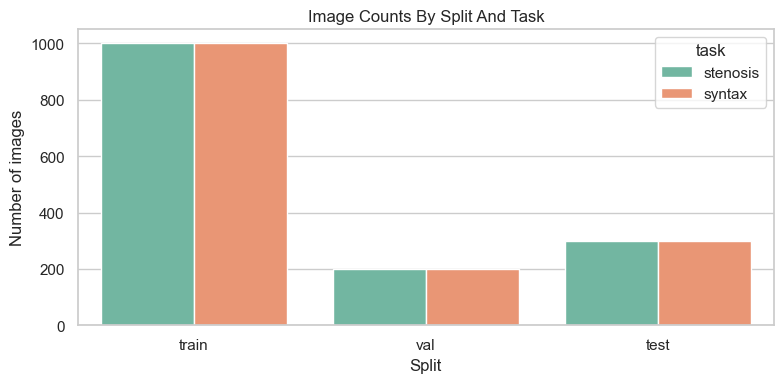

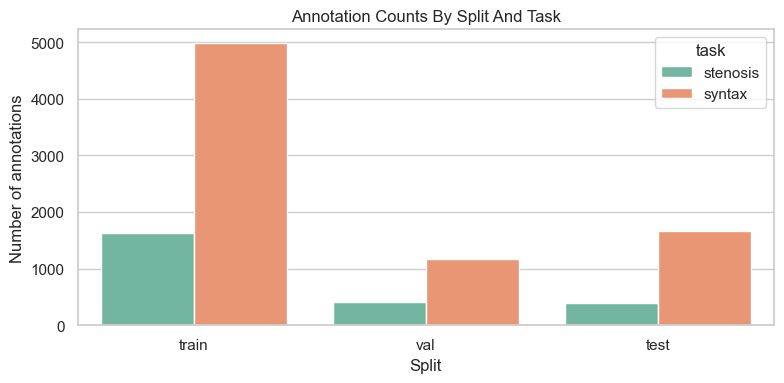

In [7]:
inventory_checks = inventory_df.copy()
inventory_checks["dir_vs_json_match"] = inventory_checks["dir_images"] == inventory_checks["json_images"]
inventory_checks["has_file_integrity_issues"] = (
    (inventory_checks["missing_image_files"] > 0)
    | (inventory_checks["extra_image_files"] > 0)
    | (inventory_checks["orphan_annotation_image_ids"] > 0)
)

display(inventory_checks)

plt.figure(figsize=(8, 4))
sns.barplot(data=inventory_df, x="split", y="json_images", hue="task", order=SPLITS)
plt.title("Image Counts By Split And Task")
plt.xlabel("Split")
plt.ylabel("Number of images")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=inventory_df, x="split", y="json_annotations", hue="task", order=SPLITS)
plt.title("Annotation Counts By Split And Task")
plt.xlabel("Split")
plt.ylabel("Number of annotations")
plt.tight_layout()
plt.show()


## Core EDA (Primary Focus)


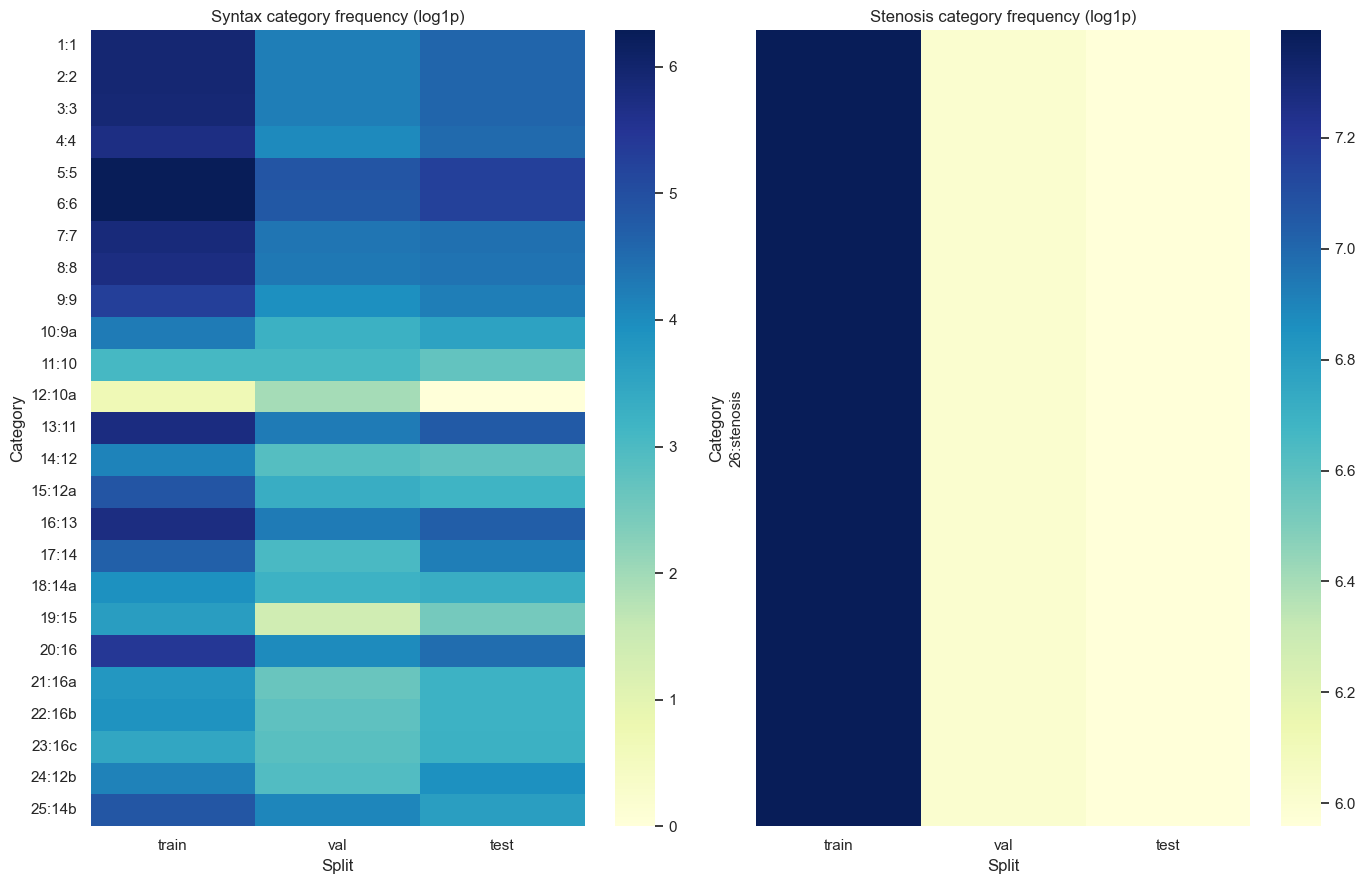

,task,split,total_annotations,top1_share,top3_share,entropy_bits,effective_categories
0,syntax,train,4976,0.107918,0.288786,4.141229,17.645507
1,syntax,val,1168,0.111301,0.284247,4.269945,19.292194
2,syntax,test,1672,0.116627,0.300239,4.225257,18.703773
3,stenosis,train,1625,1.000000,1.000000,-0.000000,1.000000
4,stenosis,val,406,1.000000,1.000000,-0.000000,1.000000
5,stenosis,test,386,1.000000,1.000000,-0.000000,1.000000


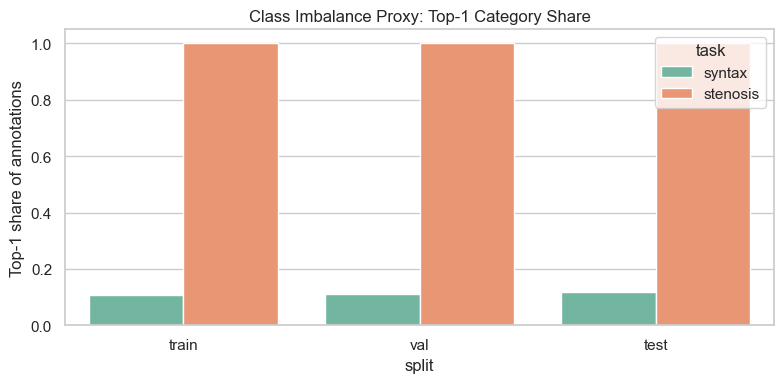

In [8]:
category_counts = (
    all_annotations.groupby(["task", "split", "category_id", "category_name"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
)

fig, axes = plt.subplots(1, len(TASKS), figsize=(7 * len(TASKS), 9), squeeze=False)

for ax, task in zip(axes[0], TASKS):
    task_counts = category_counts[category_counts["task"] == task].copy()
    pivot = (
        task_counts.pivot_table(index="category_id", columns="split", values="count", fill_value=0)
        .reindex(columns=SPLITS, fill_value=0)
        .sort_index()
    )

    label_lookup = (
        task_counts[["category_id", "category_name"]]
        .drop_duplicates()
        .set_index("category_id")["category_name"]
        .to_dict()
    )
    yticklabels = [f"{cid}:{label_lookup.get(cid, 'unknown')}" for cid in pivot.index]

    sns.heatmap(
        np.log1p(pivot),
        cmap="YlGnBu",
        cbar=True,
        ax=ax,
        yticklabels=yticklabels,
        xticklabels=SPLITS,
    )
    ax.set_title(f"{task.capitalize()} category frequency (log1p)")
    ax.set_xlabel("Split")
    ax.set_ylabel("Category")

plt.tight_layout()
plt.show()

imbalance_rows: list[dict] = []
for task in TASKS:
    for split in SPLITS:
        split_counts = category_counts[(category_counts["task"] == task) & (category_counts["split"] == split)]
        total = split_counts["count"].sum()
        probs = split_counts["count"].to_numpy(dtype=float)

        if total > 0:
            probs = probs / total
            entropy_bits = float(-(probs * np.log2(np.clip(probs, 1e-12, None))).sum())
            effective_categories = float(2 ** entropy_bits)
            top1_share = float(split_counts["count"].max() / total)
            top3_share = float(split_counts.sort_values("count", ascending=False).head(3)["count"].sum() / total)
        else:
            entropy_bits = np.nan
            effective_categories = np.nan
            top1_share = np.nan
            top3_share = np.nan

        imbalance_rows.append(
            {
                "task": task,
                "split": split,
                "total_annotations": int(total),
                "top1_share": top1_share,
                "top3_share": top3_share,
                "entropy_bits": entropy_bits,
                "effective_categories": effective_categories,
            }
        )

imbalance_df = pd.DataFrame(imbalance_rows)
display(imbalance_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=imbalance_df, x="split", y="top1_share", hue="task", order=SPLITS)
plt.title("Class Imbalance Proxy: Top-1 Category Share")
plt.ylabel("Top-1 share of annotations")
plt.tight_layout()
plt.show()


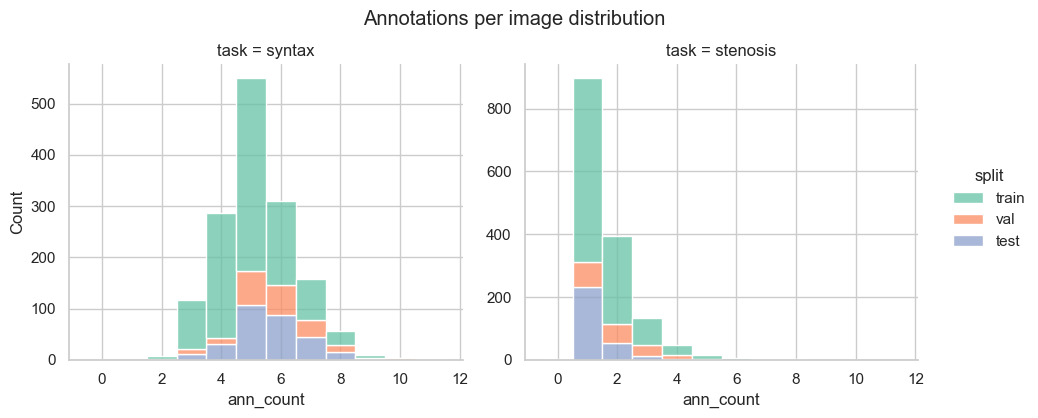

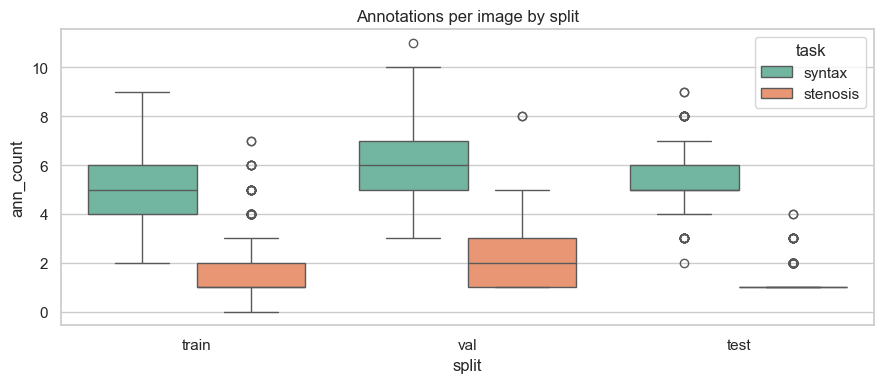

,task,split,min,median,mean,max
0,stenosis,test,1,1.0,1.286667,4
1,stenosis,train,0,1.0,1.625000,7
2,stenosis,val,1,2.0,2.030000,8
3,syntax,test,2,5.0,5.573333,9
4,syntax,train,2,5.0,4.976000,9
5,syntax,val,3,6.0,5.840000,11


In [9]:
ann_per_image = (
    all_images_meta[["task", "split", "id"]]
    .rename(columns={"id": "image_id"})
    .merge(
        all_annotations.groupby(["task", "split", "image_id"], as_index=False)
        .size()
        .rename(columns={"size": "ann_count"}),
        on=["task", "split", "image_id"],
        how="left",
    )
)
ann_per_image["ann_count"] = ann_per_image["ann_count"].fillna(0).astype(int)

g = sns.displot(
    data=ann_per_image,
    x="ann_count",
    hue="split",
    col="task",
    multiple="stack",
    discrete=True,
    facet_kws={"sharey": False},
    height=4,
    aspect=1.2,
)
g.fig.suptitle("Annotations per image distribution", y=1.04)
plt.show()

plt.figure(figsize=(9, 4))
sns.boxplot(data=ann_per_image, x="split", y="ann_count", hue="task", order=SPLITS)
plt.title("Annotations per image by split")
plt.tight_layout()
plt.show()

ann_summary = (
    ann_per_image.groupby(["task", "split"])["ann_count"]
    .agg(["min", "median", "mean", "max"])
    .reset_index()
)
display(ann_summary)


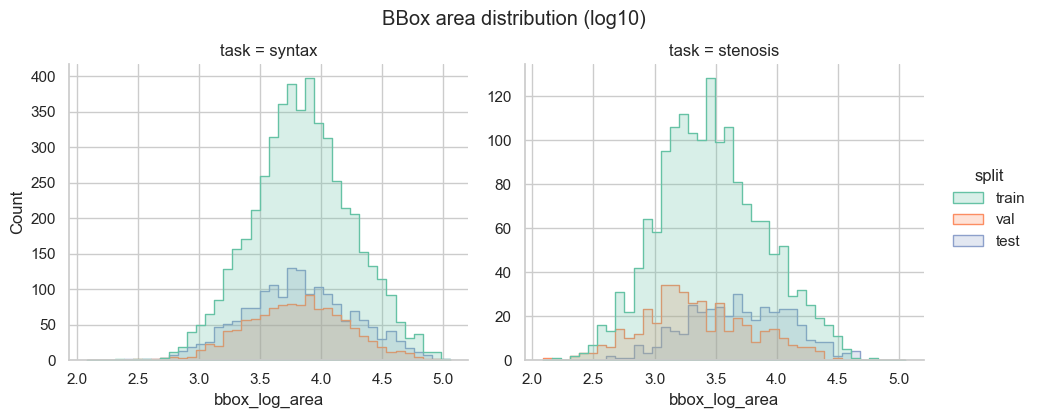

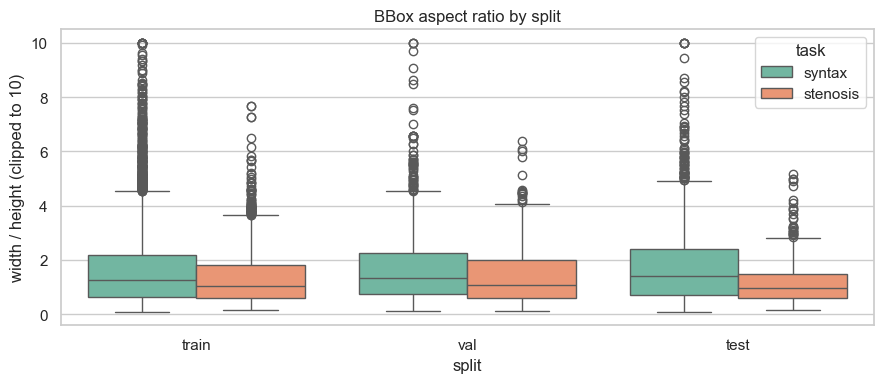

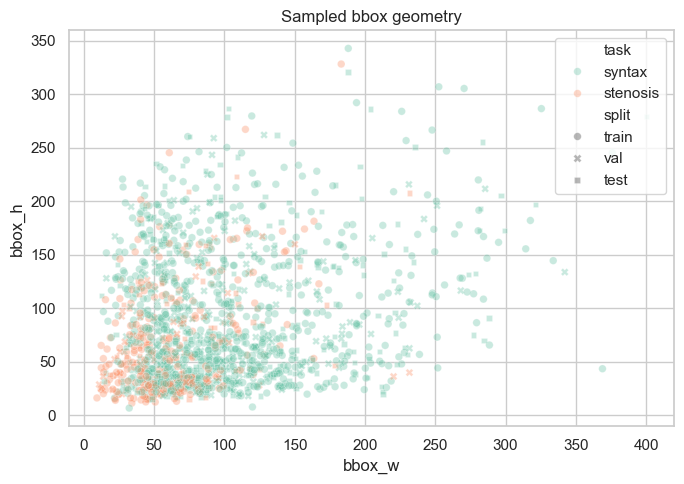

In [10]:
bbox_df = all_annotations.dropna(subset=["bbox_w", "bbox_h"]).copy()
bbox_df = bbox_df[(bbox_df["bbox_w"] > 0) & (bbox_df["bbox_h"] > 0)].copy()
bbox_df["bbox_area"] = bbox_df["bbox_w"] * bbox_df["bbox_h"]
bbox_df["bbox_log_area"] = np.log10(np.clip(bbox_df["bbox_area"], 1.0, None))
bbox_df["bbox_aspect_ratio"] = np.clip(bbox_df["bbox_aspect_ratio"], 0, 10)

g = sns.displot(
    data=bbox_df,
    x="bbox_log_area",
    hue="split",
    col="task",
    kind="hist",
    bins=40,
    element="step",
    facet_kws={"sharey": False},
    height=4,
    aspect=1.2,
)
g.fig.suptitle("BBox area distribution (log10)", y=1.04)
plt.show()

plt.figure(figsize=(9, 4))
sns.boxplot(data=bbox_df, x="split", y="bbox_aspect_ratio", hue="task", order=SPLITS)
plt.title("BBox aspect ratio by split")
plt.ylabel("width / height (clipped to 10)")
plt.tight_layout()
plt.show()

sample_bbox = bbox_df.sample(n=min(1500, len(bbox_df)), random_state=RANDOM_SEED)
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=sample_bbox,
    x="bbox_w",
    y="bbox_h",
    hue="task",
    style="split",
    alpha=0.35,
    s=30,
)
plt.title("Sampled bbox geometry")
plt.tight_layout()
plt.show()


,task,split,mode,count
0,stenosis,test,L,300
1,stenosis,train,L,699
2,stenosis,train,RGB,301
3,stenosis,val,L,200
4,syntax,test,L,300
5,syntax,train,L,451
6,syntax,train,RGB,549
7,syntax,val,L,200


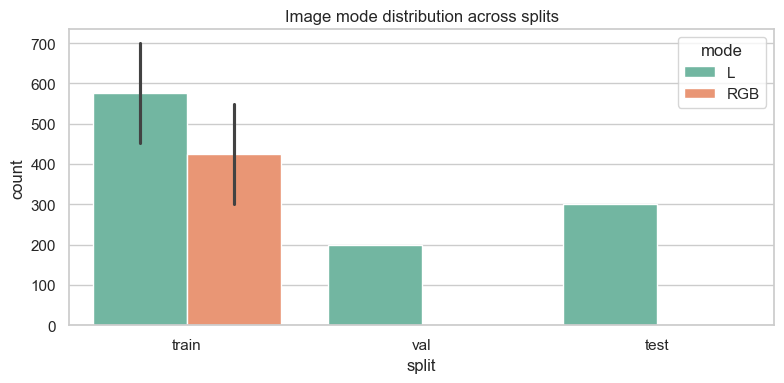

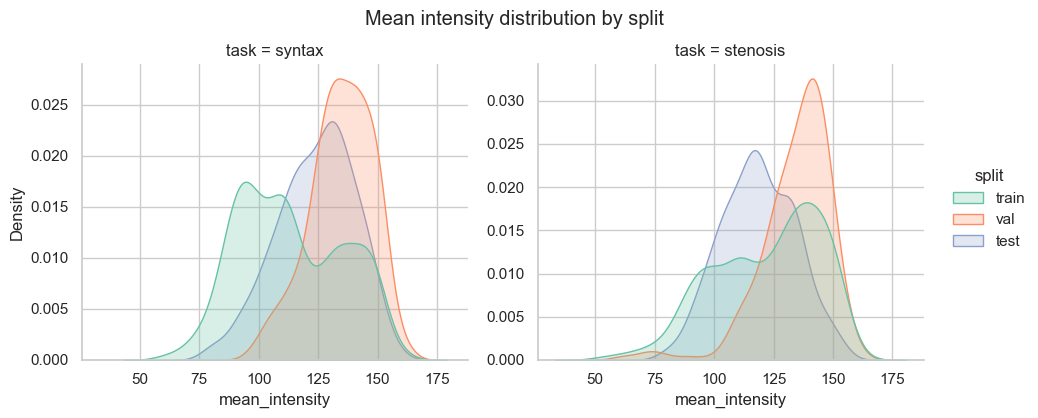

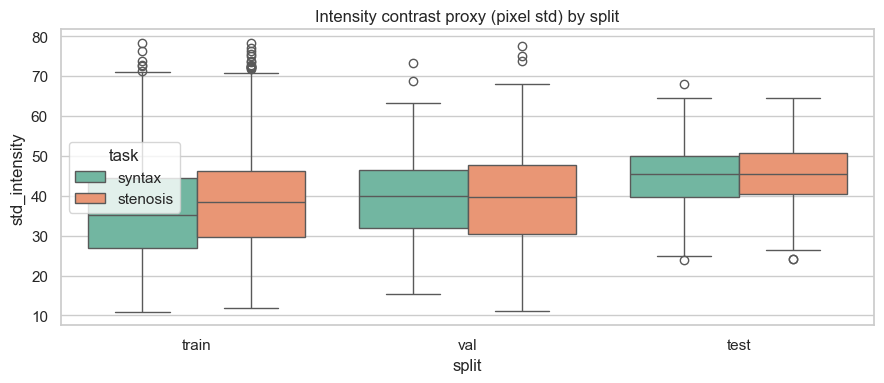

,task,split,mean_intensity_z_vs_train,contrast_z_vs_train
0,syntax,train,0.000000,0.000000
1,syntax,val,0.970782,0.278263
2,syntax,test,0.491203,0.728985
3,stenosis,train,0.000000,0.000000
4,stenosis,val,0.548620,0.113565
5,stenosis,test,-0.154614,0.535368


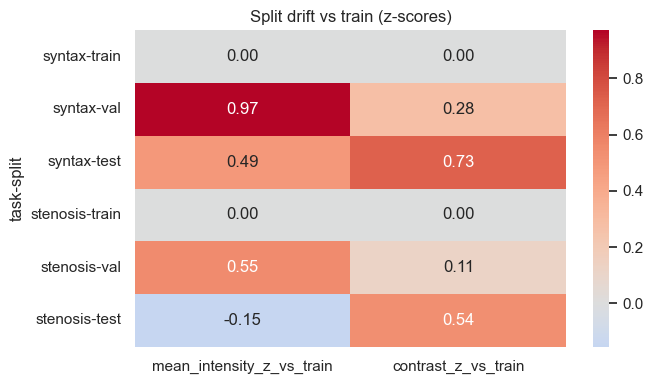

In [11]:
mode_counts = (
    all_image_stats.groupby(["task", "split", "mode"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
)
display(mode_counts)

plt.figure(figsize=(8, 4))
sns.barplot(data=mode_counts, x="split", y="count", hue="mode", order=SPLITS)
plt.title("Image mode distribution across splits")
plt.tight_layout()
plt.show()

g = sns.displot(
    data=all_image_stats,
    x="mean_intensity",
    hue="split",
    col="task",
    kind="kde",
    fill=True,
    common_norm=False,
    facet_kws={"sharey": False},
    height=4,
    aspect=1.2,
)
g.fig.suptitle("Mean intensity distribution by split", y=1.04)
plt.show()

plt.figure(figsize=(9, 4))
sns.boxplot(data=all_image_stats, x="split", y="std_intensity", hue="task", order=SPLITS)
plt.title("Intensity contrast proxy (pixel std) by split")
plt.tight_layout()
plt.show()

drift_stats = (
    all_image_stats.groupby(["task", "split"], as_index=False)
    .agg(
        mean_intensity_mean=("mean_intensity", "mean"),
        mean_intensity_std=("mean_intensity", "std"),
        contrast_mean=("std_intensity", "mean"),
        contrast_std=("std_intensity", "std"),
    )
)

drift_rows = []
for task in TASKS:
    task_stats = drift_stats[drift_stats["task"] == task].set_index("split")
    train_mu = task_stats.loc["train", "mean_intensity_mean"]
    train_sigma = max(float(task_stats.loc["train", "mean_intensity_std"]), 1e-6)
    train_c_mu = task_stats.loc["train", "contrast_mean"]
    train_c_sigma = max(float(task_stats.loc["train", "contrast_std"]), 1e-6)

    for split in SPLITS:
        row = task_stats.loc[split]
        drift_rows.append(
            {
                "task": task,
                "split": split,
                "mean_intensity_z_vs_train": float((row["mean_intensity_mean"] - train_mu) / train_sigma),
                "contrast_z_vs_train": float((row["contrast_mean"] - train_c_mu) / train_c_sigma),
            }
        )

drift_df = pd.DataFrame(drift_rows)
display(drift_df)

drift_heatmap = drift_df.set_index(["task", "split"])[["mean_intensity_z_vs_train", "contrast_z_vs_train"]]

plt.figure(figsize=(7, 4))
sns.heatmap(drift_heatmap, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Split drift vs train (z-scores)")
plt.tight_layout()
plt.show()


### Pairplot-Style Feature Relationship View (Inspired by `local EDA notebook`)

This mirrors your preferred style and shows interactions between key per-image features, with split as the hue class.


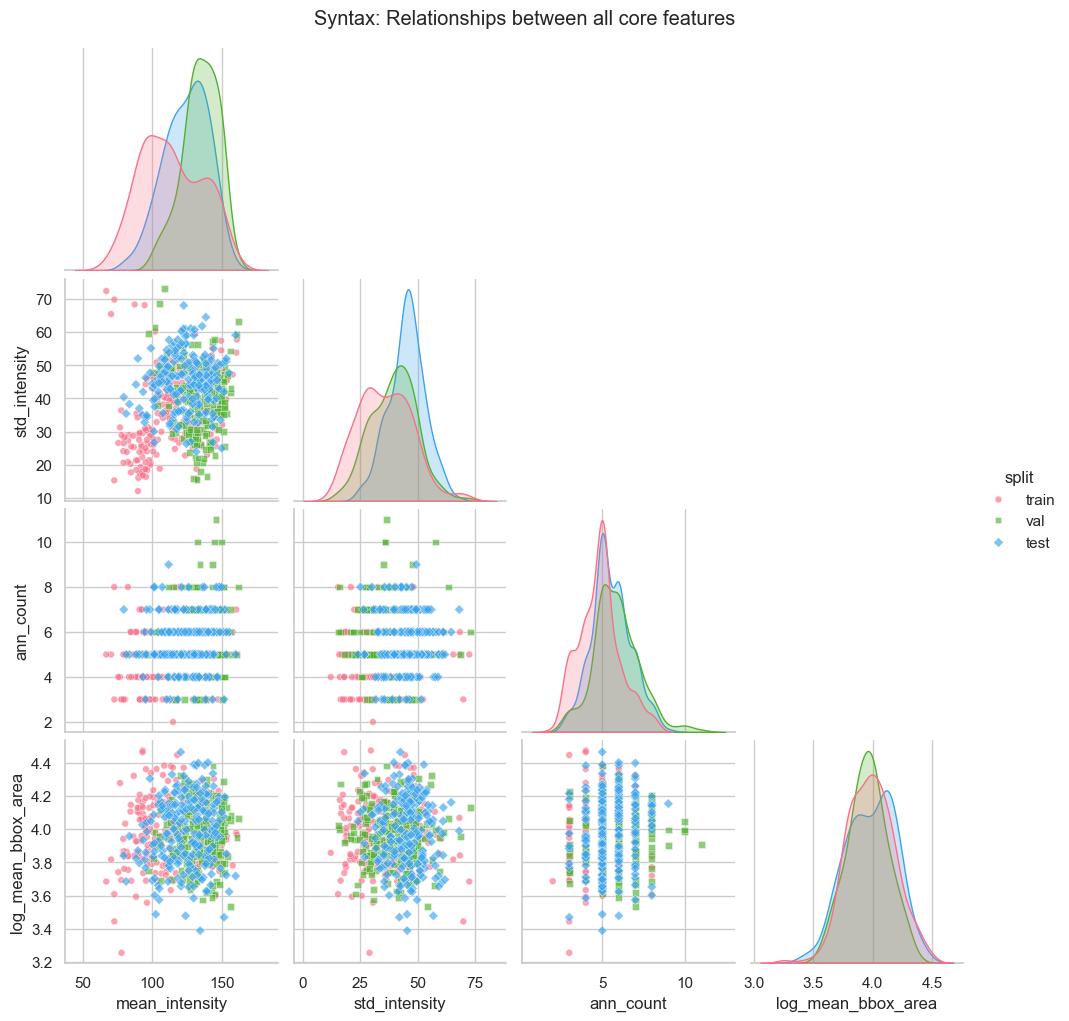

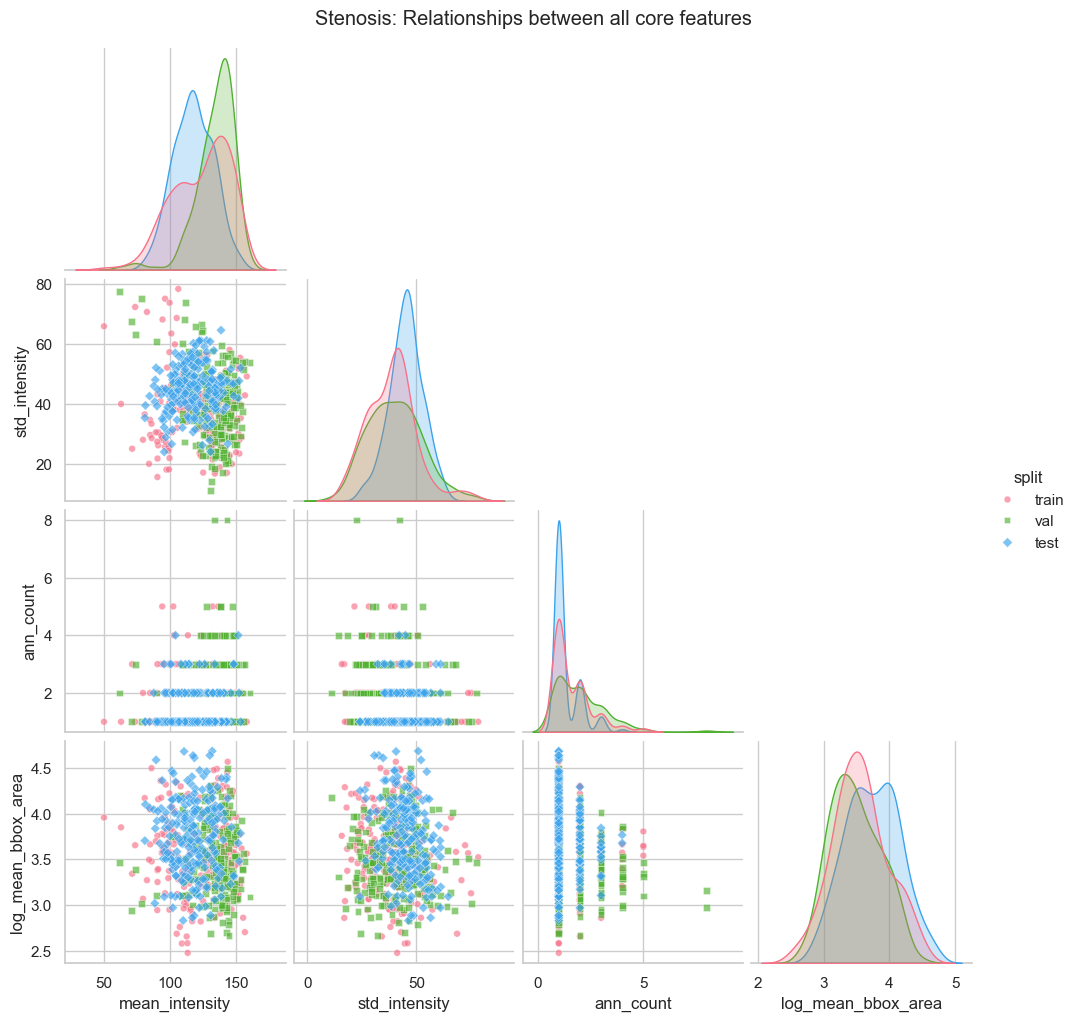

In [12]:
image_id_to_file = all_images_meta[["task", "split", "id", "file_name"]].rename(columns={"id": "image_id"})
image_ann_counts = ann_per_image.merge(
    image_id_to_file,
    on=["task", "split", "image_id"],
    how="left",
)[["task", "split", "file_name", "ann_count"]]

bbox_by_image = (
    all_annotations.groupby(["task", "split", "image_file_name"], as_index=False)
    .agg(
        mean_bbox_area=("bbox_area_calc", "mean"),
        mean_bbox_aspect=("bbox_aspect_ratio", "mean"),
    )
    .rename(columns={"image_file_name": "file_name"})
)

pairplot_df = (
    all_image_stats.merge(image_ann_counts, on=["task", "split", "file_name"], how="left")
    .merge(bbox_by_image, on=["task", "split", "file_name"], how="left")
)

pairplot_df["ann_count"] = pairplot_df["ann_count"].fillna(0)
pairplot_df["mean_bbox_area"] = pairplot_df["mean_bbox_area"].fillna(0)
pairplot_df["mean_bbox_aspect"] = pairplot_df["mean_bbox_aspect"].fillna(1.0)
pairplot_df["log_mean_bbox_area"] = np.log10(np.clip(pairplot_df["mean_bbox_area"], 1.0, None))

feature_cols = ["mean_intensity", "std_intensity", "ann_count", "log_mean_bbox_area"]

for task in TASKS:
    task_df = pairplot_df[pairplot_df["task"] == task].copy()

    # Keep pairplot readable and balanced across splits.
    sampled_parts = []
    for split_name, split_df in task_df.groupby("split", sort=False):
        n = min(len(split_df), 220)
        sampled_part = split_df.sample(n=n, random_state=RANDOM_SEED).copy()
        sampled_part["split"] = split_name
        sampled_parts.append(sampled_part)

    sampled = pd.concat(sampled_parts, ignore_index=True)

    grid = sns.pairplot(
        sampled[feature_cols + ["split"]],
        hue="split",
        palette="husl",
        markers=["o", "s", "D"],
        corner=True,
        plot_kws={"alpha": 0.65, "s": 24},
        diag_kws={"fill": True},
    )
    grid.fig.suptitle(
        f"{task.capitalize()}: Relationships between all core features",
        y=1.02,
    )
    plt.show()


## Data Quality Findings


In [13]:
within_split_dup_counts = (
    all_image_stats.groupby(["task", "split", "md5"]).size().reset_index(name="n")
)
within_split_dup_counts = within_split_dup_counts[within_split_dup_counts["n"] > 1]
within_split_dup_counts = (
    within_split_dup_counts.groupby(["task", "split"]).size().reset_index(name="within_split_exact_duplicates")
)

rgb_counts = (
    all_image_stats.assign(is_rgb=all_image_stats["mode"].eq("RGB").astype(int))
    .groupby(["task", "split"], as_index=False)["is_rgb"]
    .sum()
    .rename(columns={"is_rgb": "rgb_images"})
)

quality_summary = inventory_df.copy()
quality_summary = quality_summary.merge(within_split_dup_counts, on=["task", "split"], how="left")
quality_summary = quality_summary.merge(rgb_counts, on=["task", "split"], how="left")
quality_summary = quality_summary.merge(drift_df, on=["task", "split"], how="left")

quality_summary["within_split_exact_duplicates"] = quality_summary["within_split_exact_duplicates"].fillna(0).astype(int)
quality_summary["rgb_images"] = quality_summary["rgb_images"].fillna(0).astype(int)
quality_summary["intensity_drift_flag"] = quality_summary["mean_intensity_z_vs_train"].abs() > 1.0

mode_shift_by_task = {}
for task in TASKS:
    task_rgb = quality_summary[quality_summary["task"] == task].set_index("split")["rgb_images"].to_dict()
    mode_shift_by_task[task] = (
        task_rgb.get("train", 0) > 0
        and task_rgb.get("val", 0) == 0
        and task_rgb.get("test", 0) == 0
    )

quality_summary["task_mode_shift_flag"] = quality_summary["task"].map(mode_shift_by_task)

display(
    quality_summary[
        [
            "task",
            "split",
            "json_images",
            "json_annotations",
            "images_without_annotations",
            "missing_image_files",
            "extra_image_files",
            "orphan_annotation_image_ids",
            "within_split_exact_duplicates",
            "rgb_images",
            "mean_intensity_z_vs_train",
            "contrast_z_vs_train",
            "intensity_drift_flag",
            "task_mode_shift_flag",
        ]
    ]
)

findings = []
for task in TASKS:
    task_q = quality_summary[quality_summary["task"] == task]
    missing = int(task_q["missing_image_files"].sum())
    orphan = int(task_q["orphan_annotation_image_ids"].sum())
    no_ann = int(task_q["images_without_annotations"].sum())
    dup = int(task_q["within_split_exact_duplicates"].sum())
    mode_shift = bool(task_q["task_mode_shift_flag"].max())

    findings.append(
        {
            "task": task,
            "missing_files": missing,
            "orphan_annotations": orphan,
            "images_without_annotations": no_ann,
            "within_split_exact_duplicate_groups": dup,
            "mode_shift_train_vs_valtest": mode_shift,
        }
    )

findings_df = pd.DataFrame(findings)
display(findings_df)


,task,split,json_images,json_annotations,images_without_annotations,missing_image_files,extra_image_files,orphan_annotation_image_ids,within_split_exact_duplicates,rgb_images,mean_intensity_z_vs_train,contrast_z_vs_train,intensity_drift_flag,task_mode_shift_flag
0,stenosis,test,300,386,0,0,0,0,0,0,-0.154614,0.535368,False,True
1,stenosis,train,1000,1625,3,0,0,0,3,301,0.000000,0.000000,False,True
2,stenosis,val,200,406,0,0,0,0,0,0,0.548620,0.113565,False,True
3,syntax,test,300,1672,0,0,0,0,0,0,0.491203,0.728985,False,True
4,syntax,train,1000,4976,0,0,0,0,5,549,0.000000,0.000000,False,True
5,syntax,val,200,1168,0,0,0,0,0,0,0.970782,0.278263,False,True


,task,missing_files,orphan_annotations,images_without_annotations,within_split_exact_duplicate_groups,mode_shift_train_vs_valtest
0,syntax,0,0,0,5,True
1,stenosis,0,0,3,3,True


## Leakage Analysis (Secondary Focus)

Method:
1. Exact duplicate detection by cross-split `md5` matching.
2. Near-duplicate candidate generation by `phash` Hamming distance.
3. Candidate scoring by `SSIM` and Pearson correlation.
4. Tiering with defaults:
   - `high`: exact duplicate OR (`phash<=2`, `ssim>=0.96`, `corr>=0.98`)
   - `medium`: (`phash<=4`, `ssim>=0.92`, `corr>=0.94`)
   - `low`: (`phash<=6`, `ssim>=0.88`, `corr>=0.90`)


In [14]:
@lru_cache(maxsize=4096)
def _load_gray(path_str: str) -> np.ndarray:
    return np.asarray(Image.open(path_str).convert("L"), dtype=np.float32)


def _safe_corrcoef(arr_a: np.ndarray, arr_b: np.ndarray) -> float:
    a = arr_a.ravel().astype(np.float64)
    b = arr_b.ravel().astype(np.float64)
    a_centered = a - a.mean()
    b_centered = b - b.mean()

    denom = np.sqrt((a_centered ** 2).sum() * (b_centered ** 2).sum())
    if denom == 0:
        return 1.0 if np.allclose(a, b) else 0.0
    return float((a_centered * b_centered).sum() / denom)

def _popcount(value: int) -> int:
    value = int(value)
    if hasattr(int, "bit_count"):
        return int(value.bit_count())
    return int(bin(value).count("1"))


def _hamming_int(a: int, b: int) -> int:
    return _popcount(int(a) ^ int(b))



def _candidate_pairs_by_phash(src_df: pd.DataFrame, tgt_df: pd.DataFrame, max_phash_dist: int) -> pd.DataFrame:
    src_records = list(src_df[["file_name", "path", "md5", "phash"]].itertuples(index=False, name=None))
    tgt_records = list(tgt_df[["file_name", "path", "md5", "phash"]].itertuples(index=False, name=None))

    rows: list[dict] = []
    for file_a, path_a, md5_a, phash_a in src_records:
        phash_a = int(phash_a)
        for file_b, path_b, md5_b, phash_b in tgt_records:
            phash_dist = _hamming_int(phash_a, int(phash_b))
            if phash_dist <= max_phash_dist:
                rows.append(
                    {
                        "file_name_a": file_a,
                        "path_a": path_a,
                        "md5_a": md5_a,
                        "phash_a": phash_a,
                        "file_name_b": file_b,
                        "path_b": path_b,
                        "md5_b": md5_b,
                        "phash_b": int(phash_b),
                        "phash_dist": int(phash_dist),
                        "md5_match": bool(md5_a == md5_b),
                    }
                )

    if rows:
        return pd.DataFrame(rows)

    return pd.DataFrame(
        columns=[
            "file_name_a",
            "path_a",
            "md5_a",
            "phash_a",
            "file_name_b",
            "path_b",
            "md5_b",
            "phash_b",
            "phash_dist",
            "md5_match",
        ]
    )


def _assign_leakage_tier(row: pd.Series) -> str:
    if row["md5_match"] or (
        row["phash_dist"] <= LEAKAGE_THRESHOLDS["high"]["phash"]
        and row["ssim"] >= LEAKAGE_THRESHOLDS["high"]["ssim"]
        and row["corr"] >= LEAKAGE_THRESHOLDS["high"]["corr"]
    ):
        return "high"

    if (
        row["phash_dist"] <= LEAKAGE_THRESHOLDS["medium"]["phash"]
        and row["ssim"] >= LEAKAGE_THRESHOLDS["medium"]["ssim"]
        and row["corr"] >= LEAKAGE_THRESHOLDS["medium"]["corr"]
    ):
        return "medium"

    if (
        row["phash_dist"] <= LEAKAGE_THRESHOLDS["low"]["phash"]
        and row["ssim"] >= LEAKAGE_THRESHOLDS["low"]["ssim"]
        and row["corr"] >= LEAKAGE_THRESHOLDS["low"]["corr"]
    ):
        return "low"

    return "none"


def find_cross_split_leakage(task: str, split_a: str, split_b: str) -> pd.DataFrame:
    src_df = IMAGE_STATS_BY_KEY[(task, split_a)][["file_name", "path", "md5", "phash"]].copy()
    tgt_df = IMAGE_STATS_BY_KEY[(task, split_b)][["file_name", "path", "md5", "phash"]].copy()

    near_candidates = _candidate_pairs_by_phash(
        src_df,
        tgt_df,
        max_phash_dist=LEAKAGE_THRESHOLDS["low"]["phash"],
    )

    exact_matches = src_df.merge(tgt_df, on="md5", suffixes=("_a", "_b"))
    if not exact_matches.empty:
        exact_matches = exact_matches.assign(
            md5_a=exact_matches["md5"],
            md5_b=exact_matches["md5"],
            phash_dist=(exact_matches["phash_a"].astype(int) ^ exact_matches["phash_b"].astype(int)).map(_popcount),
            md5_match=True,
        )[
            [
                "file_name_a",
                "path_a",
                "md5_a",
                "phash_a",
                "file_name_b",
                "path_b",
                "md5_b",
                "phash_b",
                "phash_dist",
                "md5_match",
            ]
        ]
    else:
        exact_matches = near_candidates.iloc[0:0].copy()

    candidates = pd.concat([near_candidates, exact_matches], ignore_index=True)
    candidates = candidates.drop_duplicates(subset=["file_name_a", "file_name_b"]).reset_index(drop=True)

    if candidates.empty:
        return pd.DataFrame(
            columns=[
                "task",
                "split_a",
                "split_b",
                "split_pair",
                "file_name_a",
                "file_name_b",
                "path_a",
                "path_b",
                "md5_match",
                "phash_dist",
                "ssim",
                "corr",
                "nmae",
                "leakage_tier",
            ]
        )

    ssim_scores: list[float] = []
    corr_scores: list[float] = []
    nmae_scores: list[float] = []

    for row in candidates.itertuples(index=False):
        arr_a = _load_gray(row.path_a)
        arr_b = _load_gray(row.path_b)

        ssim_scores.append(float(ssim(arr_a, arr_b, data_range=255.0)))
        corr_scores.append(_safe_corrcoef(arr_a, arr_b))
        nmae_scores.append(float(np.mean(np.abs(arr_a - arr_b)) / 255.0))

    candidates["ssim"] = ssim_scores
    candidates["corr"] = corr_scores
    candidates["nmae"] = nmae_scores
    candidates["leakage_tier"] = candidates.apply(_assign_leakage_tier, axis=1)

    candidates["task"] = task
    candidates["split_a"] = split_a
    candidates["split_b"] = split_b
    candidates["split_pair"] = f"{split_a}-{split_b}"

    tier_order = pd.CategoricalDtype(categories=["high", "medium", "low", "none"], ordered=True)
    candidates["leakage_tier"] = candidates["leakage_tier"].astype(tier_order)

    candidates = candidates.sort_values(
        ["leakage_tier", "phash_dist", "ssim", "corr"],
        ascending=[True, True, False, False],
    ).reset_index(drop=True)

    return candidates[
        [
            "task",
            "split_a",
            "split_b",
            "split_pair",
            "file_name_a",
            "file_name_b",
            "path_a",
            "path_b",
            "md5_match",
            "phash_dist",
            "ssim",
            "corr",
            "nmae",
            "leakage_tier",
        ]
    ]


,task,split_pair,candidate_pairs_scored
0,stenosis,train-val,6
1,syntax,train-val,1


,task,split_pair,leakage_tier,count
0,stenosis,train-val,high,1


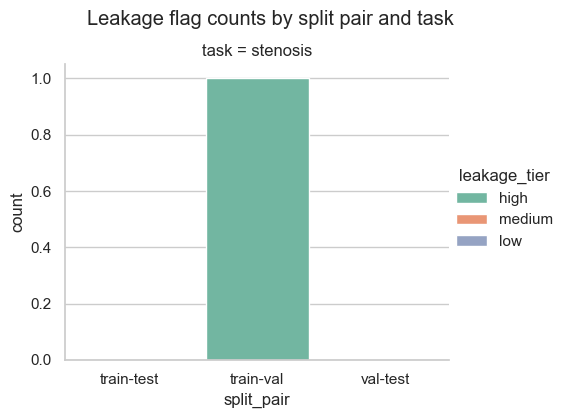

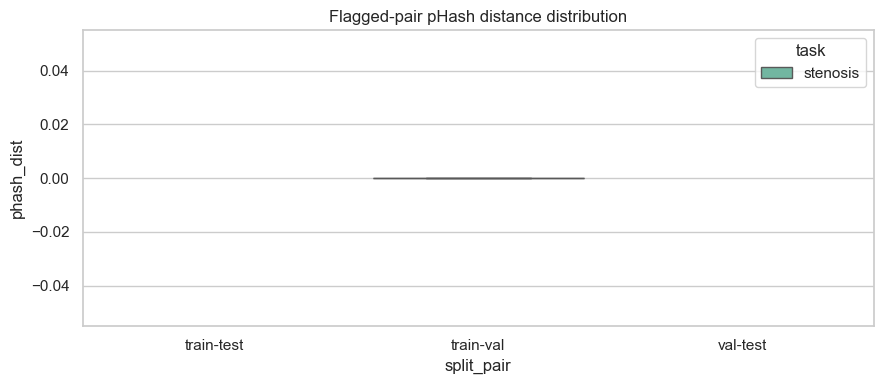

,task,split_pair,exact_duplicate_pairs
0,stenosis,train-val,1


In [15]:
SPLIT_PAIRS = [
    ("train", "test"),
    ("train", "val"),
    ("val", "test"),
]

leakage_frames: list[pd.DataFrame] = []
for task in TASKS:
    for split_a, split_b in SPLIT_PAIRS:
        pair_df = find_cross_split_leakage(task, split_a, split_b)
        leakage_frames.append(pair_df)

all_leakage = pd.concat(leakage_frames, ignore_index=True)
all_leakage["leakage_tier"] = all_leakage["leakage_tier"].astype(str)

flagged_leakage = all_leakage[all_leakage["leakage_tier"].isin(["high", "medium", "low"])].copy()

candidate_summary = (
    all_leakage.groupby(["task", "split_pair"]).size().reset_index(name="candidate_pairs_scored")
)
display(candidate_summary)

if not flagged_leakage.empty:
    leakage_summary = (
        flagged_leakage.groupby(["task", "split_pair", "leakage_tier"]).size().reset_index(name="count")
    )
    display(leakage_summary)

    g = sns.catplot(
        data=flagged_leakage,
        x="split_pair",
        hue="leakage_tier",
        col="task",
        kind="count",
        hue_order=["high", "medium", "low"],
        order=["train-test", "train-val", "val-test"],
        height=4,
        aspect=1.2,
    )
    g.fig.suptitle("Leakage flag counts by split pair and task", y=1.04)
    plt.show()

    plt.figure(figsize=(9, 4))
    sns.boxplot(
        data=flagged_leakage,
        x="split_pair",
        y="phash_dist",
        hue="task",
        order=["train-test", "train-val", "val-test"],
    )
    plt.title("Flagged-pair pHash distance distribution")
    plt.tight_layout()
    plt.show()
else:
    leakage_summary = pd.DataFrame(columns=["task", "split_pair", "leakage_tier", "count"])
    print("No flagged leakage pairs under configured thresholds.")

exact_duplicate_summary = (
    all_leakage[all_leakage["md5_match"]]
    .groupby(["task", "split_pair"])
    .size()
    .reset_index(name="exact_duplicate_pairs")
)
display(exact_duplicate_summary)


,task,split_pair,file_name_a,file_name_b,md5_match,phash_dist,ssim,corr,nmae,leakage_tier
1,stenosis,train-val,218.png,58.png,True,0,1.0,1.0,0.0,high


#### Leakage Examples: `stenosis` | `train-val`

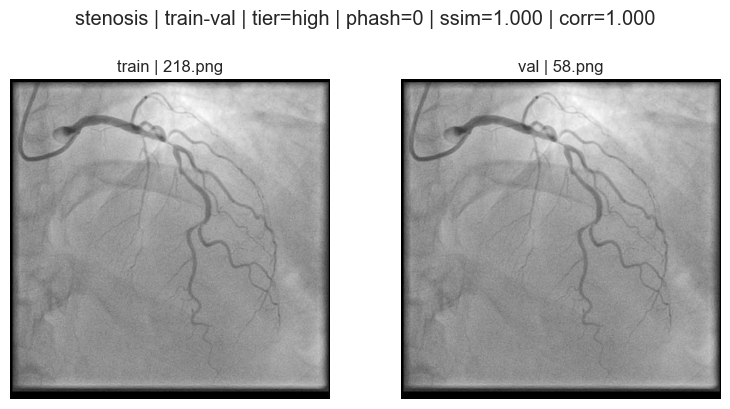

In [16]:
tier_rank = {"high": 0, "medium": 1, "low": 2}
top_flagged_pairs = flagged_leakage.copy()

if not top_flagged_pairs.empty:
    top_flagged_pairs["tier_rank"] = top_flagged_pairs["leakage_tier"].map(tier_rank)
    top_flagged_pairs = top_flagged_pairs.sort_values(
        ["tier_rank", "task", "split_pair", "phash_dist", "ssim", "corr"],
        ascending=[True, True, True, True, False, False],
    )

    display(
        top_flagged_pairs[
            [
                "task",
                "split_pair",
                "file_name_a",
                "file_name_b",
                "md5_match",
                "phash_dist",
                "ssim",
                "corr",
                "nmae",
                "leakage_tier",
            ]
        ].head(20)
    )

    def plot_leakage_examples(df: pd.DataFrame, max_examples: int = 3) -> None:
        subset = df.head(max_examples)
        for _, row in subset.iterrows():
            fig, axes = plt.subplots(1, 2, figsize=(8, 4))
            arr_a = np.asarray(Image.open(row["path_a"]).convert("L"))
            arr_b = np.asarray(Image.open(row["path_b"]).convert("L"))

            axes[0].imshow(arr_a, cmap="gray")
            axes[0].set_title(f"{row['split_a']} | {row['file_name_a']}")
            axes[0].axis("off")

            axes[1].imshow(arr_b, cmap="gray")
            axes[1].set_title(f"{row['split_b']} | {row['file_name_b']}")
            axes[1].axis("off")

            fig.suptitle(
                f"{row['task']} | {row['split_pair']} | tier={row['leakage_tier']} | "
                f"phash={row['phash_dist']} | ssim={row['ssim']:.3f} | corr={row['corr']:.3f}",
                y=1.02,
            )
            plt.tight_layout()
            plt.show()

    for task in TASKS:
        for split_pair in ["train-test", "train-val", "val-test"]:
            subset = top_flagged_pairs[
                (top_flagged_pairs["task"] == task)
                & (top_flagged_pairs["split_pair"] == split_pair)
            ]
            if subset.empty:
                continue
            display(Markdown(f"#### Leakage Examples: `{task}` | `{split_pair}`"))
            plot_leakage_examples(subset, max_examples=2)
else:
    print("No flagged pairs to visualize.")


## Final Conclusions

EDA takeaways are reported first, followed by leakage verdicts.


In [17]:
verdict_rows = []

for task in TASKS:
    task_quality = quality_summary[quality_summary["task"] == task]
    task_inventory = inventory_df[inventory_df["task"] == task]
    task_leakage = flagged_leakage[flagged_leakage["task"] == task]

    missing_files = int(task_inventory["missing_image_files"].sum())
    orphan_ann = int(task_inventory["orphan_annotation_image_ids"].sum())
    images_wo_ann = int(task_inventory["images_without_annotations"].sum())
    within_dups = int(task_quality["within_split_exact_duplicates"].sum())
    mode_shift = bool(task_quality["task_mode_shift_flag"].max())

    if missing_files == 0 and orphan_ann == 0:
        eda_health = "Structurally clean"
    else:
        eda_health = "Needs structural cleanup"

    eda_notes = []
    if images_wo_ann > 0:
        eda_notes.append(f"{images_wo_ann} images without annotations")
    if within_dups > 0:
        eda_notes.append(f"{within_dups} within-split exact-duplicate groups")
    if mode_shift:
        eda_notes.append("train contains RGB while val/test are grayscale only")
    if not eda_notes:
        eda_notes.append("no major integrity anomalies detected")

    train_test_flags = task_leakage[task_leakage["split_pair"] == "train-test"]
    train_val_flags = task_leakage[task_leakage["split_pair"] == "train-val"]

    high_tt = int((train_test_flags["leakage_tier"] == "high").sum())
    med_tt = int((train_test_flags["leakage_tier"] == "medium").sum())
    low_tt = int((train_test_flags["leakage_tier"] == "low").sum())

    if high_tt > 0:
        leakage_risk = "High (train-test)"
    elif med_tt > 0 or low_tt > 0:
        leakage_risk = "Moderate (train-test)"
    elif len(train_val_flags) > 0:
        leakage_risk = "Validation contamination risk (train-val)"
    else:
        leakage_risk = "Low detected cross-split risk"

    leakage_notes = []
    if not task_leakage.empty:
        tier_counts = task_leakage["leakage_tier"].value_counts().to_dict()
        leakage_notes.append(
            ", ".join([f"{tier}:{count}" for tier, count in sorted(tier_counts.items())])
        )
    else:
        leakage_notes.append("no flagged pairs at configured thresholds")

    recs = [
        "Keep or introduce patient/study-level group IDs for split-safe partitioning.",
        "Maintain a deterministic pre-split deduplication pass (exact + perceptual).",
    ]
    if mode_shift:
        recs.append("Normalize all images to a single channel policy before training/evaluation.")
    if len(train_val_flags) > 0:
        recs.append("Move matched train-val pairs into the same group before final split generation.")

    verdict_rows.append(
        {
            "task": task,
            "eda_health": eda_health,
            "eda_key_findings": "; ".join(eda_notes),
            "leakage_risk": leakage_risk,
            "leakage_key_findings": "; ".join(leakage_notes),
            "recommendations": " | ".join(recs),
        }
    )

verdict_df = pd.DataFrame(verdict_rows)
display(verdict_df)

summary_lines = ["### EDA Takeaways (Primary)"]
for row in verdict_rows:
    summary_lines.append(f"- **{row['task']}**: {row['eda_health']}. {row['eda_key_findings']}.")

summary_lines.append("")
summary_lines.append("### Leakage Takeaways (Secondary)")
for row in verdict_rows:
    summary_lines.append(f"- **{row['task']}**: {row['leakage_risk']}. {row['leakage_key_findings']}.")

summary_lines.append("")
summary_lines.append("### Recommended Next Steps")
summary_lines.append("- Regenerate train/val/test with patient-aware grouping if identifiers are available.")
summary_lines.append("- Add an automated leakage gate in preprocessing to block suspicious cross-split pairs.")
summary_lines.append("- Standardize channel representation (grayscale) before model training and benchmarking.")

display(Markdown(chr(10).join(summary_lines)))


,task,eda_health,eda_key_findings,leakage_risk,leakage_key_findings,recommendations
0,syntax,Structurally clean,5 within-split exact-duplicate groups; train c...,Low detected cross-split risk,no flagged pairs at configured thresholds,Keep or introduce patient/study-level group ID...
1,stenosis,Structurally clean,3 images without annotations; 3 within-split e...,Validation contamination risk (train-val),high:1,Keep or introduce patient/study-level group ID...


### EDA Takeaways (Primary)
- **syntax**: Structurally clean. 5 within-split exact-duplicate groups; train contains RGB while val/test are grayscale only.
- **stenosis**: Structurally clean. 3 images without annotations; 3 within-split exact-duplicate groups; train contains RGB while val/test are grayscale only.

### Leakage Takeaways (Secondary)
- **syntax**: Low detected cross-split risk. no flagged pairs at configured thresholds.
- **stenosis**: Validation contamination risk (train-val). high:1.

### Recommended Next Steps
- Regenerate train/val/test with patient-aware grouping if identifiers are available.
- Add an automated leakage gate in preprocessing to block suspicious cross-split pairs.
- Standardize channel representation (grayscale) before model training and benchmarking.